In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("../datasets/petrol_transport_data.csv")

In [2]:
avg_petrol_price = data["avg_petrol_price_naira_per_litre"]
avg_bus_fare = data["avg_bus_fare_naira_per_drop"]

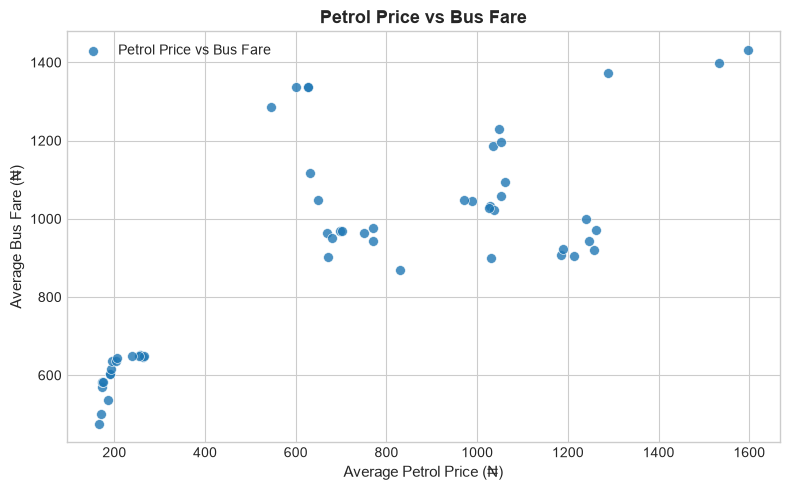

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

ax.scatter(
    avg_petrol_price,
    avg_bus_fare,
    color="#1f77b4",
    alpha=0.8,
    edgecolors="white",
    linewidth=0.5,
    s=50,
    label="Petrol Price vs Bus Fare"
)

ax.set_xlabel("Average Petrol Price (₦)", fontsize=11)
ax.set_ylabel("Average Bus Fare (₦)", fontsize=11)
ax.set_title("Petrol Price vs Bus Fare", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()

In [4]:
# Univariate Linear Regression Logic
def fit():
# Assigning Variables
    m_curr = b_curr = 0
    iterations = 200
    learning_rate = 0.0000001

    X = avg_petrol_price
    y = avg_bus_fare

    total = X.shape[0]

    # Training the Model
    for i in range(iterations):

        # Gradient Descent
        y_predicted = (m_curr * X) + b_curr
            
        md = (1 / total) * np.sum(X * (y_predicted - y))
        bd = (1 / total ) * np.sum(y_predicted - y)
            
        m_curr = m_curr - (learning_rate * md)
        b_curr = b_curr - (learning_rate * bd)
        
        # Cost Function
        cost = (1 / (2 * total)) * np.sum((y_predicted - y) ** 2)
        
        print(f"Linear Equation: y = {m_curr:.3f}x + {b_curr:.3f}. Cost: {cost:.2f}. Iteration {i}")
    return m_curr, b_curr

In [ ]:
# Predict with new data
def predict(X):
    m, b = fit()

    y = (m * X) + b
    return y